In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from pprint import pprint
import math
from tqdm import tqdm
import seaborn as sns

## Load data

In [3]:
def get_in_road_percentage(steps_df: pd.DataFrame) -> float:
    ret = steps_df["out_of_road"].value_counts(normalize=True).at[False]
    return ret

In [4]:

def get_n_sidewalk_crashes(steps_df: pd.DataFrame) -> int:
    """Count number of crash episodes to not count same crash multiple times"""
    try:
        # count number of times "crash" becomes True for some time
        n_crashes = steps_df["crash_sidewalk"].diff().value_counts().at[True]

        # need to divide by 2 beacouse diff counts twice
        n_crashes /= 2

        # just in case crash is last episode and we have 3.5 crash episodes make it 4
        n_crashes = math.ceil(n_crashes)
    except KeyError:
        n_crashes = 0

    return n_crashes


In [5]:

def process_steps(steps_infos: list) -> dict:
    """Accepts a list of steps and returns a dict of interesting data"""

    steps_df = pd.DataFrame(steps_infos)
    steps_data = {}
    last_step = steps_df.iloc[-1]

    steps_data = {
        "termination.arrive_dest": last_step["arrive_dest"],
        "termination.timeout": last_step["max_step"],
        "route_completion": last_step["route_completion"],
        "seed": last_step["env_seed"],
        "in_road_percentage": get_in_road_percentage(steps_df),
        "n_sidewalk_crashes": get_n_sidewalk_crashes(steps_df),
    }

    return steps_data


In [6]:

def get_scenarios_df(dir: Path, flaky):
    paths = list(dir.glob("**/*.json"))

    scenarios = []
    for file_path in tqdm(paths):

        with open(file_path, "r") as f:
            scenario_data = json.load(f)

        path_split = file_path.__str__().split("/")
        if flaky:
            dir = path_split[-3]
            scenario_data["rep"] = path_split[-2]
        else:
            dir = path_split[-2]
            scenario_data["rep"] = path_split[-3]
            
        _, dr, _, dt = dir.split("_")
        scenario_data["decision_repeat"] = int(dr)
        scenario_data["dt"] = float(dt)

        scenario_data.update(process_steps(scenario_data['steps_infos']))
        scenarios.append(scenario_data)
    return pd.DataFrame(scenarios)


In [7]:
SHOW_FLAKY = False
path = Path(f"../data/not_isolated") if SHOW_FLAKY else Path(f"../data/isolated")#Path(f"../data/isolated")

df = get_scenarios_df(path, flaky=SHOW_FLAKY)
df = df.reset_index(drop=True).set_index(['rep', 'seed'], verify_integrity=True).sort_index()

100%|██████████| 2000/2000 [00:18<00:00, 107.01it/s]


In [8]:
infractions = ['n_crashed_vehicles', 'n_sidewalk_crashes', 'termination.timeout', 'in_road_percentage', ]
new_names = ["N Crashed vehicles", "N Sidewalk crashes","Timeout", "In road percentage", ]
df = df[infractions]
df = df.rename(columns=dict(zip(infractions,new_names)))

df

N Crashed vehicles  N Sidewalk crashes  Timeout  In road percentage
rep seed                                                                     
0   0                      0                   0    False                 1.0
    1                      2                   0     True                 1.0
    2                      0                   0    False                 1.0
    3                      0                   0    False                 1.0
    4                      1                   0    False                 1.0
...                      ...                 ...      ...                 ...
9   195                    0                   0    False                 1.0
    196                    0                   0    False                 1.0
    197                    0                   0    False                 1.0
    198                    2                   0    False                 1.0
    199                    0                   0    False                 1.0

[2000 rows x 4 columns]

In [9]:
# See single scenario
# df.xs(0, level='seed')

## RQ1

In [10]:
behaviours_df = df.map(str).agg(" ".join, axis=1)
behaviours_df

rep  seed
0    0       0 0 False 1.0
     1        2 0 True 1.0
     2       0 0 False 1.0
     3       0 0 False 1.0
     4       1 0 False 1.0
                 ...      
9    195     0 0 False 1.0
     196     0 0 False 1.0
     197     0 0 False 1.0
     198     2 0 False 1.0
     199     0 0 False 1.0
Length: 2000, dtype: object

In [11]:

behaviours_count = behaviours_df.groupby("seed").nunique().rename("n_behaviors").to_frame()
# behaviours_count['nondeterministic'] = behaviours_count['n_behaviors'] > 1
values = behaviours_count['n_behaviors'].value_counts()
values = values.to_frame().transpose()
values.to_numpy().flatten()

array([200])

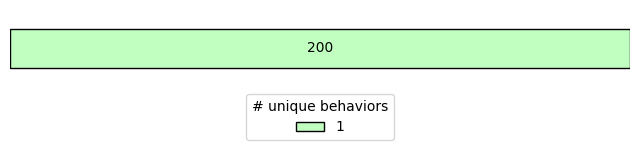

In [12]:
fig, ax = plt.subplots(figsize=(8, 1))
palette = ["#C1FFC1", "#FFC1C1", "#FF7F7F", "#FF4040", "#DC143C"]

ax = values.plot.barh(stacked=True, edgecolor="black", color=palette, ax=ax)
# ax.get_legend().remove()

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=len(palette),
    title="# unique behaviors",
)  # Adjust bbox_to_anchor if needed

text_props = dict(
    horizontalalignment="center", verticalalignment="center", color="black"
)
ax.annotate("200", xy=(100, 0), **text_props)

ax.set_axis_off()
ax.margins(x=0, y=0)
ax.get_figure().savefig("rq1.pdf", bbox_inches="tight")

## RQ2

In [13]:
# standard deviation for each scenario
stds = df.groupby('seed').std()
stds

,N Crashed vehicles,N Sidewalk crashes,Timeout,In road percentage
seed,,,,
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
...,...,...,...,...
195,0.0,0.0,0.0,0.0
196,0.0,0.0,0.0,0.0
197,0.0,0.0,0.0,0.0


### No mask

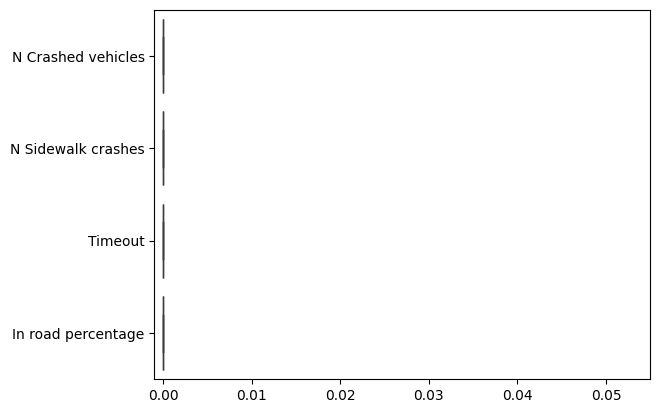

In [14]:
ax = sns.boxplot(data=stds, orient="h")
ax.set_xlim(-0.001)
ax.get_figure().savefig("rq2.pdf", bbox_inches="tight")
# ax.set(xscale="log")

### Masked
Nondeterministic only

In [15]:
sns.boxplot(data=stds[behaviours_count['nondeterministic']], orient="h")

KeyError: 'nondeterministic'